## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2008-2019_filled.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2008-2019.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,indices_image_date,indices_lat,indices_lon,lst_day_new,lst_night_new,lst_image_date,lst_lat,lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,monthly_lst_lat,monthly_lst_lon,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crespadoro,veneto,11.17678,45.65353,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crespadoro,veneto,11.17678,45.65353,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,saint martino buon albergo,veneto,11.09543,45.42378,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
wnv_file.head()

,lau1,nuts2,dt_placement,case
0,adria,veneto,2008-06-01,0
1,adria,veneto,2008-06-16,0
2,adria,veneto,2008-07-01,0
3,adria,veneto,2008-07-16,0
4,adria,veneto,2008-08-01,0


In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', ], inplace = True)

In [9]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crespadoro,veneto,11.17678,45.65353,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crespadoro,veneto,11.17678,45.65353,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,saint martino buon albergo,veneto,11.09543,45.42378,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
wnv_file.head(5)

,lau1,nuts2,dt_placement,case
0,adria,veneto,2008-06-01,0
1,adria,veneto,2008-06-16,0
2,adria,veneto,2008-07-01,0
3,adria,veneto,2008-07-16,0
4,adria,veneto,2008-08-01,0


In [12]:
## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


['barbarano vicentino', 'biancade', 'brescia', 'castelnuovo bariano', 'frassinelle', 'giacciano in barucchella', 'godega saint urbano', 'localita ca barzoni', 'mantova', 'marghera', 'masera', 'mestre', 'monastier', 'monteforte', 'montegrotto', 'palermo', 'pra maggiore', 'saint elena da silea', 'saint pietri viminario', 'saint pietro da morubi', 'saint pietro morubio', 'selvazzano', 'vialeggio sul mincio', 'vo euganeo']

Length: 24


In [13]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('barbarano vicentino','barbarano mossano'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('biancade','roncade'))
wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'brescia')].index , inplace=True)
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('castelnuovo bariano','castelnovo bariano'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('frassinelle','frassinelle polesine'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('giacciano in barucchella','giacciano con baruchella'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('godega saint urbano','godega da saint urbano'))
wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'localita ca barzoni')].index , inplace=True)
wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'mantova')].index , inplace=True)
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('marghera','venezia'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera','masera da padova'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('mestre','venezia'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monastier','monastier da treviso'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monteforte','monteforte da alpone'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('montegrotto','montegrotto terme'))
wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'palermo')].index , inplace=True)
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('pra maggiore','pramaggiore'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint elena da silea','saint elena'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietri viminario','saint pietro viminario'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro morubio','saint pietro da morubio'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubi','saint pietro da morubio'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano','selvazzano dentro'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vialeggio sul mincio','valeggio sul mincio'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vo euganeo','vo'))


In [14]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['masera da padovada sul piave', 'saint pietro da morubioo', 'selvazzano dentro dentro']

Length: 3


In [15]:
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubioo','saint pietro da morubio'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano dentro dentro','selvazzano dentro'))
wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera da padovada sul piave','masera da padova'))

In [16]:
## Check again

names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_wnv_file:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [17]:
merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )

In [18]:
merged

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crespadoro,veneto,11.17678,45.65353,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,crespadoro,veneto,11.17678,45.65353,2008-01-16,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,saint martino buon albergo,veneto,11.09543,45.42378,2008-01-01,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236731,saint pietro da morubio,veneto,11.20096,45.24276,2019-12-16,2019,12,0.345361,0.065034,-0.293280,-0.065034,0.316665,0.053806,-0.263096,-0.053806,0.095411,0.084998,0.073621,0.084998,13932.0,13764.0,13845.692308,13509.700000,14272.684211,13663.100000,14809.157895,13812.916667,14828.583333,14100.100000,2012.744939,11.812954,12.000068,NaN
236732,pove da grappa,veneto,11.73823,45.83013,2019-12-01,2019,12,0.437186,0.148594,-0.349057,-0.148594,0.401371,0.101893,-0.318622,-0.101893,0.084708,0.068754,0.108637,0.068754,14119.0,13842.0,13894.866667,13553.071429,14165.722222,13766.157895,14425.000000,13854.291667,14554.444444,13885.428571,2105.626981,20.800747,79.315920,NaN
236733,pove da grappa,veneto,11.73823,45.83013,2019-12-16,2019,12,0.249379,0.341239,-0.221712,-0.341239,0.221545,0.291305,-0.194731,-0.291305,0.092723,0.201198,0.101377,0.201198,13914.0,13648.0,13894.866667,13553.071429,14165.722222,13766.157895,14425.000000,13854.291667,14554.444444,13885.428571,2225.571692,117.107266,117.149645,NaN
236734,pozzoleone,veneto,11.67640,45.66637,2019-12-01,2019,12,0.262722,0.176622,-0.226437,-0.176622,0.230521,0.115580,-0.214693,-0.115580,0.021710,0.034776,0.013166,0.034776,14507.0,13951.0,13891.642857,13438.583333,14307.066667,13617.187500,14650.789474,13817.150000,14742.400000,14004.285714,2096.818845,22.310624,96.877908,NaN


In [19]:
merged = fillna(merged,{'case': 0})

In [20]:
merged['case'].value_counts()

0.0    236271
1.0       436
2.0        23
4.0         3
6.0         3
Name: case, dtype: int64

In [21]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [22]:
dataset = grouped.mean()

In [23]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2008-01-01,abano terme,veneto,11.795390,45.357830,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2008-01-01,adria,veneto,12.049403,45.070483,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2008-01-01,affi,veneto,10.776730,45.556800,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2008-01-01,agna,veneto,11.965390,45.175310,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2008-01-01,agordo,veneto,12.059120,46.313990,2008.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164443,2019-12-16,zevio,veneto,11.127335,45.353970,2019.0,12.0,0.396140,0.170329,-0.341296,-0.170329,0.326675,0.135319,-0.279695,-0.135319,0.040432,0.031954,0.032209,0.031954,13959.5,13740.0,13916.566667,13445.588889,14311.540179,13645.277632,14780.961988,13817.035526,14859.108333,14043.285714,2091.478254,53.456704,60.071381,0.0
164444,2019-12-16,zimella,veneto,11.358050,45.347770,2019.0,12.0,0.187854,0.105364,-0.114976,-0.105364,0.225832,0.077743,-0.162152,-0.077743,0.085087,0.064487,0.083286,0.064487,13934.0,13772.0,13899.692308,13478.363636,14341.941176,13630.388889,14856.681818,13834.045455,15018.300000,14109.857143,2100.493727,23.390857,23.659128,0.0
164445,2019-12-16,zoppe da cadore,veneto,12.178780,46.388350,2019.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
164446,2019-12-16,zovencedo,veneto,11.494300,45.437980,2019.0,12.0,0.281425,-0.035619,-0.201909,0.035619,0.300694,0.028742,-0.210404,-0.028742,0.091435,0.103179,0.141708,0.103179,13893.0,13899.0,13872.250000,13632.090909,14234.400000,13825.777778,14584.272727,13992.333333,14644.100000,14173.333333,2143.057917,23.186623,23.352794,0.0


In [24]:
dataset = dataset.astype({'case': 'int'})

In [25]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [26]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [27]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [28]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2008-01-01,abano terme,veneto,11.79539,45.35783,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.86645,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981
1,2008-01-01,adria,veneto,12.04940,45.07048,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.65336,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981
2,2008-01-01,affi,veneto,10.77673,45.55680,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.81410,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981
3,2008-01-01,agna,veneto,11.96539,45.17531,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.73306,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981
4,2008-01-01,agordo,veneto,12.05912,46.31399,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,47.85821,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164443,2019-12-16,zevio,veneto,11.12733,45.35397,2019,12,0.396140,0.170329,-0.341296,-0.170329,0.326675,0.135319,-0.279695,-0.135319,0.040432,0.031954,0.032209,0.031954,13959.5,13740.0,13916.566667,13445.588889,14311.540179,13645.277632,14780.961988,13817.035526,14859.108333,14043.285714,2091.478254,53.456704,60.071381,0,16,51,46.69904,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023
164444,2019-12-16,zimella,veneto,11.35805,45.34777,2019,12,0.187854,0.105364,-0.114976,-0.105364,0.225832,0.077743,-0.162152,-0.077743,0.085087,0.064487,0.083286,0.064487,13934.0,13772.0,13899.692308,13478.363636,14341.941176,13630.388889,14856.681818,13834.045455,15018.300000,14109.857143,2100.493727,23.390857,23.659128,0,16,51,46.74854,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023
164445,2019-12-16,zoppe da cadore,veneto,12.17878,46.38835,2019,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,51,47.96042,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023
164446,2019-12-16,zovencedo,veneto,11.49430,45.43798,2019,12,0.281425,-0.035619,-0.201909,0.035619,0.300694,0.028742,-0.210404,-0.028742,0.091435,0.103179,0.141708,0.103179,13893.0,13899.0,13872.250000,13632.090909,14234.400000,13825.777778,14584.272727,13992.333333,14644.100000,14173.333333,2143.057917,23.186623,23.352794,0,16,51,46.86928,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023


<AxesSubplot:>

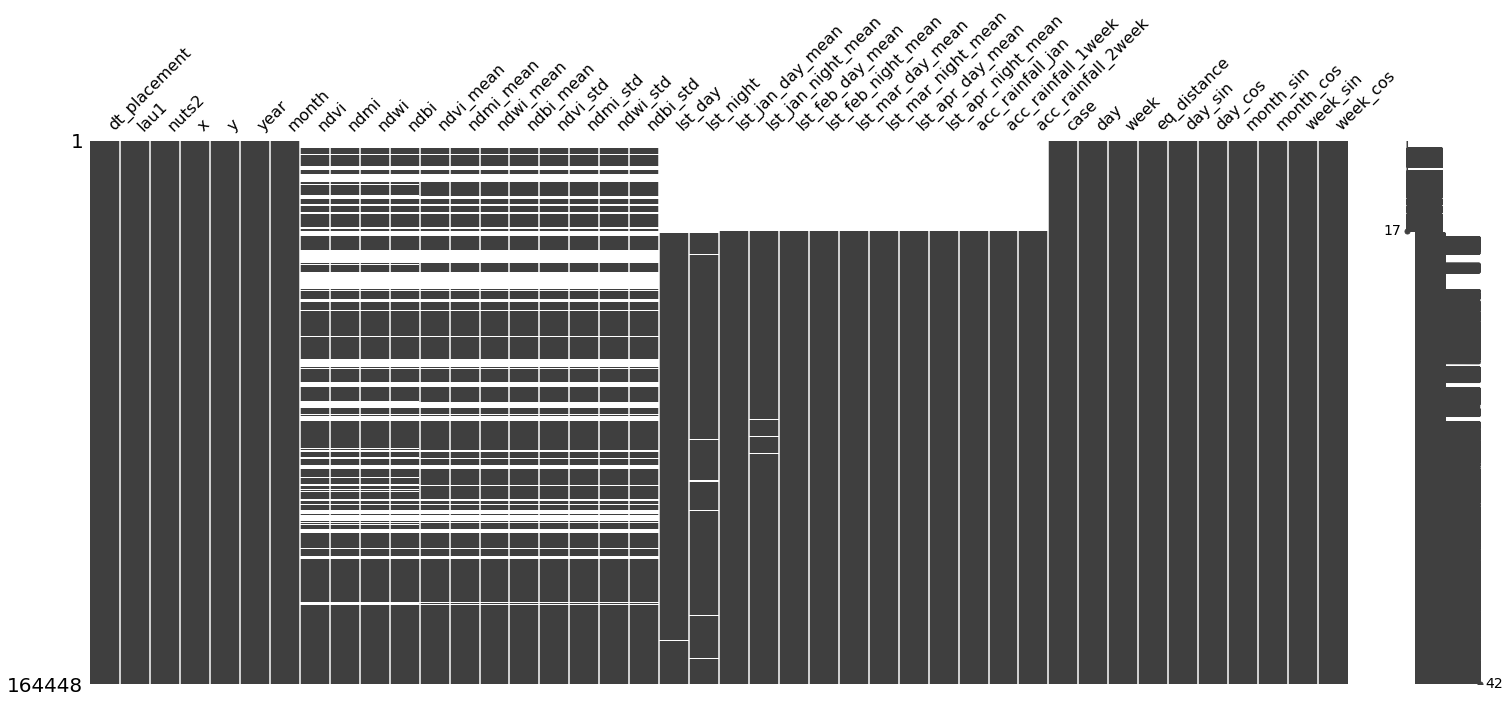

In [30]:
missingno.matrix(dataset)

In [31]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [32]:
df_demographics

,lau1,nuts3,nuts2,population
0,abano terme,padova,veneto,"19,349"
1,adria,rovigo,veneto,"20,233"
2,affi,verona,veneto,"2,297"
3,agna,padova,veneto,"3,400"
4,agordo,belluno,veneto,"4,249"
...,...,...,...,...
576,zimella,verona,veneto,"4,834"
577,zoldo alto,belluno,veneto,999
578,zoppe da cadore,belluno,veneto,265
579,zovencedo,vicenza,veneto,796


In [33]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_LOWER}'").copy()

In [35]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [36]:
df_demographics_nuts2

,lau1,population
0,abano terme,"19,349"
1,adria,"20,233"
2,affi,"2,297"
3,agna,"3,400"
4,agordo,"4,249"
...,...,...
576,zimella,"4,834"
577,zoldo alto,999
578,zoppe da cadore,265
579,zovencedo,796


In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['alpago', 'barbarano mossano', 'borgo veneto', 'brenzone sul garda', 'costermano sul garda', 'quero vas', 'val da zoldo', 'val liona']

Length: 8


In [38]:
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'alpago', 'population':6858}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('mossano','barbarano mossano'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'borgo veneto', 'population':7000}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'brenzone sul garda', 'population':2452}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('costermano','costermano sul garda'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('quero','quero vas'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val da zoldo', 'population':3242}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val liona', 'population':3047}, ignore_index=True)


In [39]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [40]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

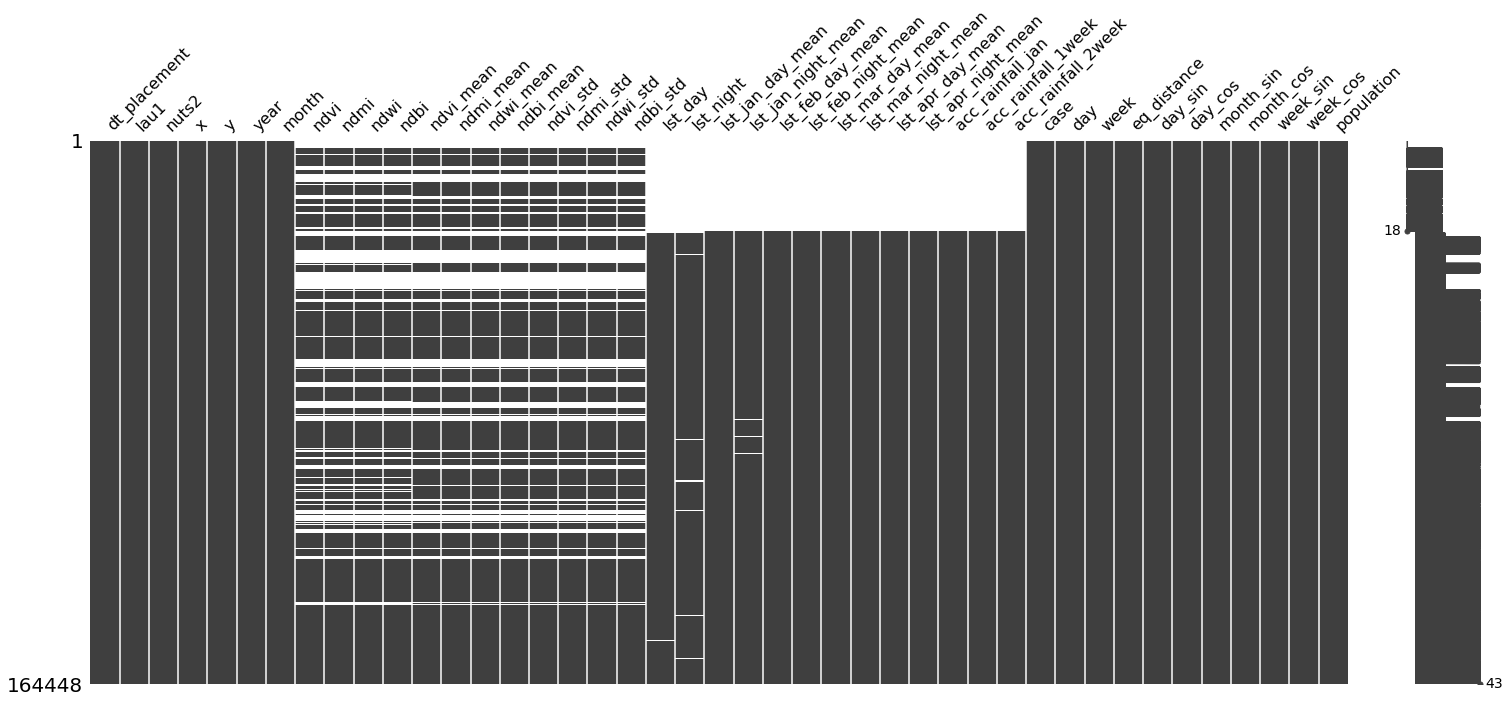

In [41]:
missingno.matrix(dataset)

In [42]:
missing = describe_dataframe(dataset)

In [43]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population
0,2008-01-01,abano terme,veneto,11.79539,45.35783,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.86645,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981,"19,349"
1,2008-01-01,adria,veneto,12.04940,45.07048,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.65336,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981,"20,233"
2,2008-01-01,affi,veneto,10.77673,45.55680,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.81410,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981,"2,297"
3,2008-01-01,agna,veneto,11.96539,45.17531,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.73306,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981,"3,400"
4,2008-01-01,agordo,veneto,12.05912,46.31399,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,47.85821,0.201299,0.979530,5.000000e-01,0.866025,0.118273,0.992981,"4,249"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164443,2019-12-16,zevio,veneto,11.12733,45.35397,2019,12,0.396140,0.170329,-0.341296,-0.170329,0.326675,0.135319,-0.279695,-0.135319,0.040432,0.031954,0.032209,0.031954,13959.5,13740.0,13916.566667,13445.588889,14311.540179,13645.277632,14780.961988,13817.035526,14859.108333,14043.285714,2091.478254,53.456704,60.071381,0,16,51,46.69904,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023,"14,413"
164444,2019-12-16,zimella,veneto,11.35805,45.34777,2019,12,0.187854,0.105364,-0.114976,-0.105364,0.225832,0.077743,-0.162152,-0.077743,0.085087,0.064487,0.083286,0.064487,13934.0,13772.0,13899.692308,13478.363636,14341.941176,13630.388889,14856.681818,13834.045455,15018.300000,14109.857143,2100.493727,23.390857,23.659128,0,16,51,46.74854,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023,"4,834"
164445,2019-12-16,zoppe da cadore,veneto,12.17878,46.38835,2019,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,51,47.96042,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023,265
164446,2019-12-16,zovencedo,veneto,11.49430,45.43798,2019,12,0.281425,-0.035619,-0.201909,0.035619,0.300694,0.028742,-0.210404,-0.028742,0.091435,0.103179,0.141708,0.103179,13893.0,13899.0,13872.250000,13632.090909,14234.400000,13825.777778,14584.272727,13992.333333,14644.100000,14173.333333,2143.057917,23.186623,23.352794,0,16,51,46.86928,-0.101168,-0.994869,-2.449294e-16,1.000000,-0.234886,0.972023,796


In [44]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2008-2019.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2008-01-01,1
1,12.049403,45.070483,2008-01-01,1
2,10.776730,45.556800,2008-01-01,7
3,11.965390,45.175310,2008-01-01,1
4,12.059120,46.313990,2008-01-01,8
...,...,...,...,...
164443,11.127335,45.353970,2019-12-16,1
164444,11.358050,45.347770,2019-12-16,1
164445,12.178780,46.388350,2019-12-16,1
164446,11.494300,45.437980,2019-12-16,1


In [45]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [46]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [47]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492665983


In [48]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [49]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [50]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [51]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,mosq_pred
0,2008-01-01,abano terme,veneto,11.79539,45.35783,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.86645,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"19,349",1
1,2008-01-01,adria,veneto,12.04940,45.07048,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.65336,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"20,233",1
2,2008-01-01,affi,veneto,10.77673,45.55680,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.81410,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"2,297",7
3,2008-01-01,agna,veneto,11.96539,45.17531,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,46.73306,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"3,400",4
4,2008-01-01,agordo,veneto,12.05912,46.31399,2008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,47.85821,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"4,249",14


<AxesSubplot:>

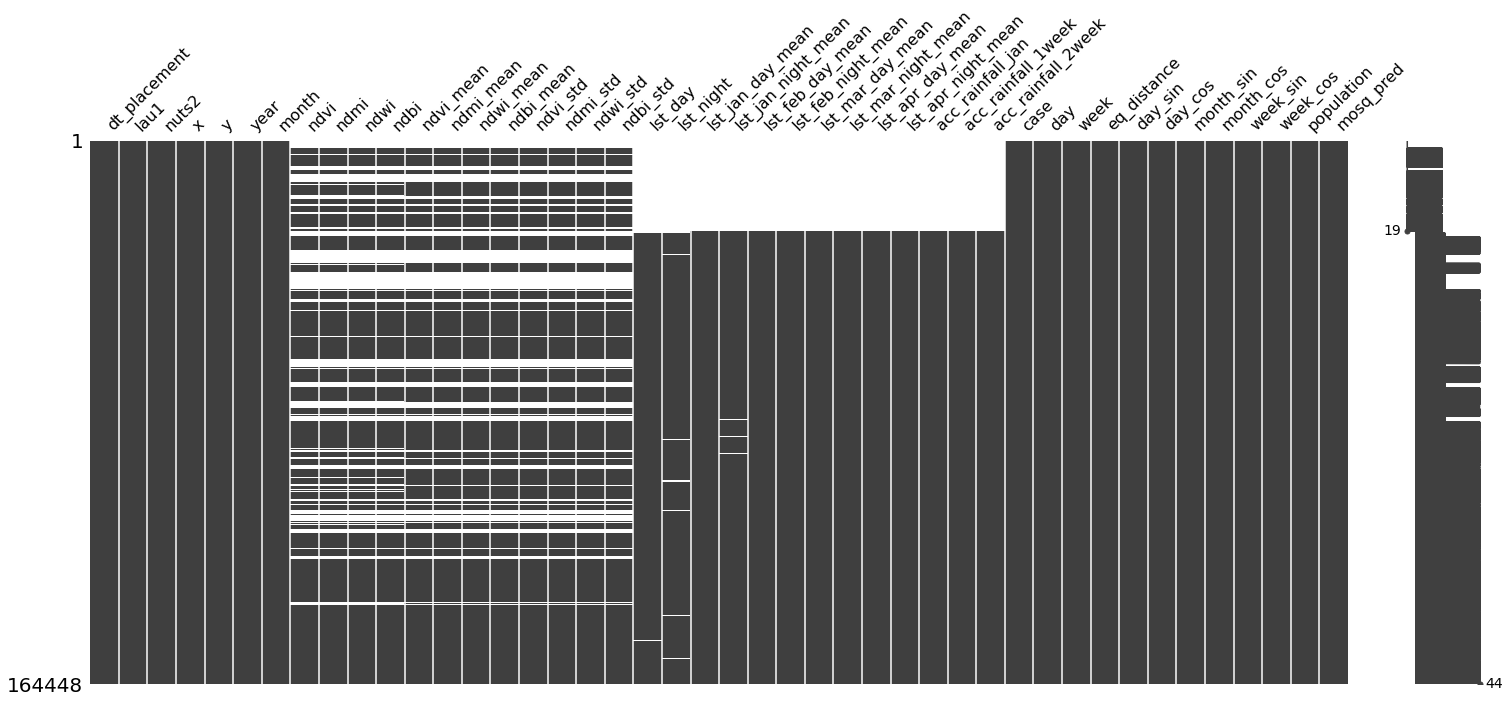

In [52]:
missingno.matrix(dataset)

In [56]:
dataset.reset_index(inplace=True, drop=True)

In [53]:
dataset = calculate_mosq_previous(dataset)

In [54]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

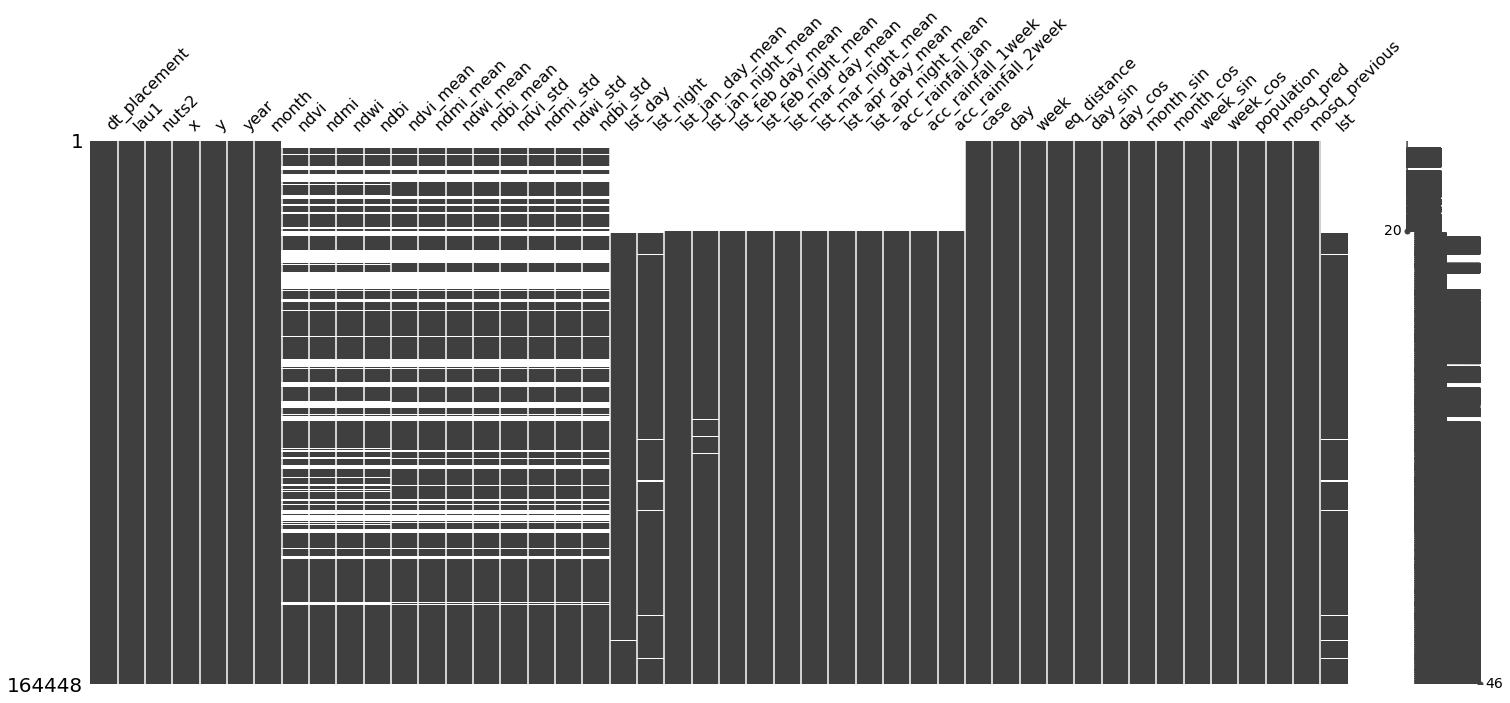

In [55]:
missingno.matrix(dataset)

In [56]:
dataset['case'].value_counts()

0    164200
1       231
2        15
4         1
6         1
Name: case, dtype: int64

In [57]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [58]:
dataset = convert_multiple_cases(dataset)

In [59]:
dataset['case'].value_counts()

0    164200
1       271
Name: case, dtype: int64

In [60]:
cols = dataset.columns

In [61]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'population', 'mosq_pred',
       'mosq_previous', 'lst'],
      dtype='object')

In [62]:
len(cols)

46

In [63]:
# check columns

In [65]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'population',
                 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [66]:
len(final_columns)

46

In [67]:
dataset_final = dataset[final_columns].copy()

In [68]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,"19,349",46.86645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
1,12.04940,45.07048,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,"20,233",46.65336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,"2,297",46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,"3,400",46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0,0
4,12.05912,46.31399,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164466,11.85230,45.42086,2018-08-16,veneto,padova,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,"206,192",46.94179,0.572754,0.198785,-0.486131,-0.198785,0.485612,0.143995,-0.42883,-0.143995,0.093341,0.063704,0.063937,0.063704,27.553333,32.656667,22.45,7.967704,0.778333,7.483333,-1.683111,15.053796,1.854921,26.279667,12.725238,55.488571,100.88727,1174.808946,1,2,1
164467,11.85230,45.42086,2018-08-16,veneto,padova,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,"206,192",46.94179,0.572754,0.198785,-0.486131,-0.198785,0.485612,0.143995,-0.42883,-0.143995,0.093341,0.063704,0.063937,0.063704,27.553333,32.656667,22.45,7.967704,0.778333,7.483333,-1.683111,15.053796,1.854921,26.279667,12.725238,55.488571,100.88727,1174.808946,1,2,1
164468,11.85230,45.42086,2018-08-16,veneto,padova,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,"206,192",46.94179,0.572754,0.198785,-0.486131,-0.198785,0.485612,0.143995,-0.42883,-0.143995,0.093341,0.063704,0.063937,0.063704,27.553333,32.656667,22.45,7.967704,0.778333,7.483333,-1.683111,15.053796,1.854921,26.279667,12.725238,55.488571,100.88727,1174.808946,1,2,1
164469,11.85230,45.42086,2018-08-16,veneto,padova,16,8,33,2018,-0.101168,-0.994869,-0.866025,-0.500000,-0.696551,-0.717507,"206,192",46.94179,0.572754,0.198785,-0.486131,-0.198785,0.485612,0.143995,-0.42883,-0.143995,0.093341,0.063704,0.063937,0.063704,27.553333,32.656667,22.45,7.967704,0.778333,7.483333,-1.683111,15.053796,1.854921,26.279667,12.725238,55.488571,100.88727,1174.808946,1,2,1


In [69]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv", encoding = enc, index = False)